In [1]:
from pathlib import Path
import pandas as pd

BASE = Path.home() / "projekty" / "dzietnosc-polska"
RAW  = BASE / "data" / "raw" / "prognoza_gus_2023_2060"

def znajdz(wzorzec):
    trafienia = list(RAW.glob(wzorzec))
    if not trafienia:
        raise FileNotFoundError(f"Nie znaleziono pliku pasujacego do: {wzorzec} w {RAW}")
    return trafienia[0]

PLIKI = {
    "główny": (znajdz("5-tabela_zbiorcza.xlsx"), "Główny scenariusz", "Płeć", "Wiek", "Ludność_",   "Mężczyźni", "Kobiety"),
    "niski":  (znajdz("Data*niski.xlsx"),        "Low",               "Sex",  "Age",  "Population_", "Males",     "Females"),
    "wysoki": (znajdz("Data*wysoki.xlsx"),       "High",              "Sex",  "Age",  "Population_", "Males",     "Females"),
}

def wskazniki(sciezka, arkusz, kol_plec, kol_wiek, prefix, val_m, val_k):
    df = pd.read_excel(sciezka, sheet_name=arkusz)
    df["_w"] = df[kol_wiek].apply(lambda w: 90 if str(w) == "90+" else int(w))
    out = []
    for col in [c for c in df.columns if c.startswith(prefix)]:
        rok = int(col.split("_")[1])
        g = df.groupby([kol_plec, "_w"])[col].sum().reset_index()
        M = g[g[kol_plec] == val_m].set_index("_w")[col]
        K = g[g[kol_plec] == val_k].set_index("_w")[col]
        total = M.sum() + K.sum()
        prod  = M[(M.index >= 18) & (M.index <= 64)].sum() + K[(K.index >= 18) & (K.index <= 59)].sum()
        pop65 = M[M.index >= 65].sum() + K[K.index >= 65].sum()
        p1564 = M[(M.index >= 15) & (M.index <= 64)].sum() + K[(K.index >= 15) & (K.index <= 64)].sum()
        out.append({"rok": rok, "ludnosc": int(total),
                    "udzial_65": pop65 / total * 100,
                    "dr_ekonomiczny": (total - prod) / prod * 100,
                    "oadr": pop65 / p1564 * 100})
    return pd.DataFrame(out)

ramki = []
for nazwa, args in PLIKI.items():
    w = wskazniki(*args)
    w["scenariusz"] = nazwa
    ramki.append(w)
proj = pd.concat(ramki, ignore_index=True)[["scenariusz", "rok", "ludnosc", "udzial_65", "dr_ekonomiczny", "oadr"]]

# walidacja: odtworzenie kotwic GUS (inaczej metoda błędna)
def sprawdz(scen, rok, kol, oczek, tol):
    v = proj[(proj.scenariusz == scen) & (proj.rok == rok)].iloc[0][kol]
    assert abs(v - oczek) <= tol, f"WALIDACJA NIEUDANA: {scen} {rok} {kol}={v:.2f}, oczekiwano ~{oczek}"
sprawdz("główny", 2022, "dr_ekonomiczny", 70.0, 1.0)
sprawdz("główny", 2060, "dr_ekonomiczny", 105.0, 1.0)
sprawdz("niski",  2060, "ludnosc", 26_700_000, 200_000)
sprawdz("wysoki", 2060, "ludnosc", 34_800_000, 200_000)
print("Walidacja OK — kotwice GUS odtworzone.")

(BASE / "data" / "processed").mkdir(parents=True, exist_ok=True)
proj.to_csv(BASE / "data" / "processed" / "projekcja_obciazenie_2022_2060.csv", index=False)
proj[proj.rok.isin([2022, 2060])]

Walidacja OK — kotwice GUS odtworzone.


,scenariusz,rok,ludnosc,udzial_65,dr_ekonomiczny,oadr
0,główny,2022,37766327,19.470930,70.354139,29.895948
38,główny,2060,30925606,32.562311,104.766378,59.563575
39,niski,2022,37766327,19.470930,70.354139,29.895948
77,niski,2060,26654317,33.682060,100.304331,60.495506
78,wysoki,2022,37766327,19.470930,70.354139,29.895948
116,wysoki,2060,34796858,31.871869,110.248282,59.632822


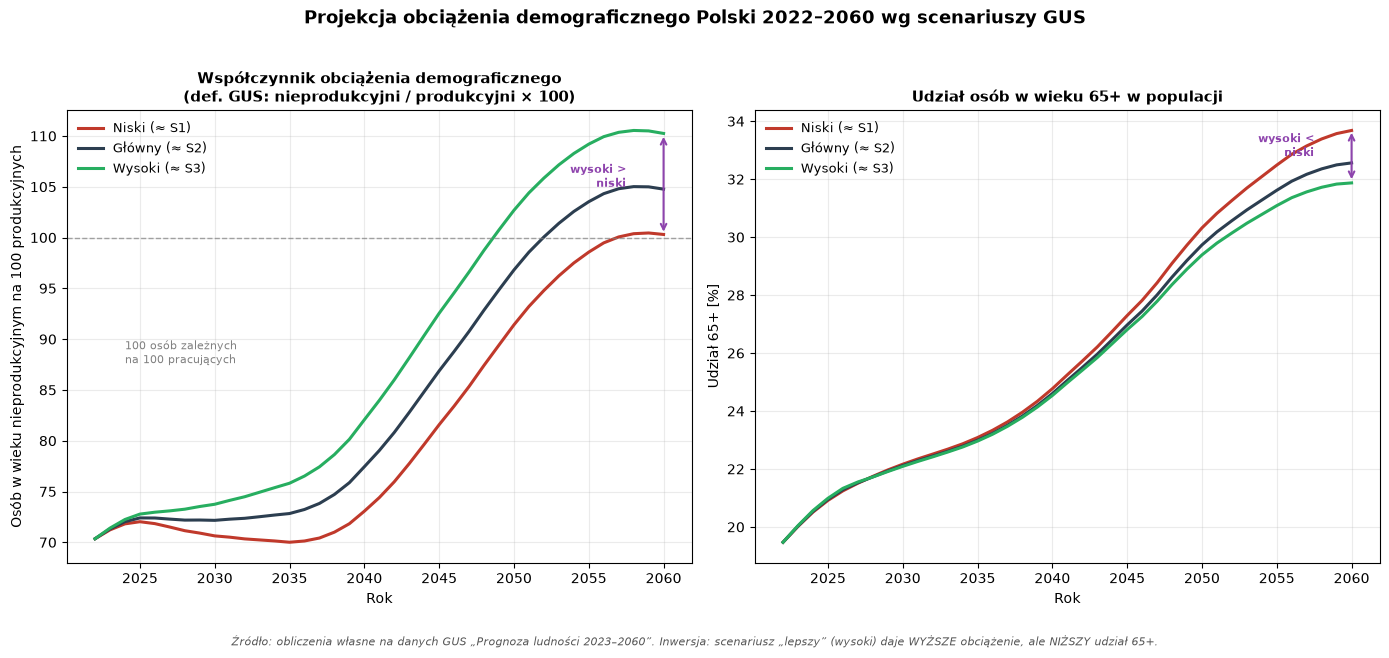

In [3]:
import matplotlib.pyplot as plt

PROJ = BASE / "data" / "processed" / "projekcja_obciazenie_2022_2060.csv"
FIG  = BASE / "figures" / "08_obciazenie_scenariusze.png"
FIG.parent.mkdir(parents=True, exist_ok=True)   # gdyby folder figures nie istniał

proj = pd.read_csv(PROJ)

kolory    = {"niski": "#c0392b", "główny": "#2c3e50", "wysoki": "#27ae60"}
etykiety  = {"niski": "Niski (≈ S1)", "główny": "Główny (≈ S2)", "wysoki": "Wysoki (≈ S3)"}
kolejnosc = ["niski", "główny", "wysoki"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- Panel lewy: DR ekonomiczny ---
for sc in kolejnosc:
    d = proj[proj.scenariusz == sc].sort_values("rok")
    ax1.plot(d.rok, d.dr_ekonomiczny, color=kolory[sc], lw=2.2, label=etykiety[sc])
ax1.axhline(100, color="grey", ls="--", lw=1, alpha=0.7)
ax1.annotate("100 osób zależnych\nna 100 pracujących", xy=(2024, 100),
             xytext=(2024, 90), fontsize=8, color="grey", va="top")
ax1.set_title("Współczynnik obciążenia demograficznego\n(def. GUS: nieprodukcyjni / produkcyjni × 100)",
              fontsize=11, fontweight="bold")
ax1.set_xlabel("Rok")
ax1.set_ylabel("Osób w wieku nieprodukcyjnym na 100 produkcyjnych")
ax1.legend(frameon=False, fontsize=9)
ax1.grid(alpha=0.25)
ax1.annotate("", xy=(2060, 110.2), xytext=(2060, 100.3),
             arrowprops=dict(arrowstyle="<->", color="#8e44ad", lw=1.5))
ax1.text(2057.5, 105, "wysoki >\nniski", fontsize=8, color="#8e44ad",
         ha="right", fontweight="bold")

# --- Panel prawy: udział 65+ ---
for sc in kolejnosc:
    d = proj[proj.scenariusz == sc].sort_values("rok")
    ax2.plot(d.rok, d.udzial_65, color=kolory[sc], lw=2.2, label=etykiety[sc])
ax2.set_title("Udział osób w wieku 65+ w populacji", fontsize=11, fontweight="bold")
ax2.set_xlabel("Rok")
ax2.set_ylabel("Udział 65+ [%]")
ax2.legend(frameon=False, fontsize=9)
ax2.grid(alpha=0.25)
ax2.annotate("", xy=(2060, 31.9), xytext=(2060, 33.7),
             arrowprops=dict(arrowstyle="<->", color="#8e44ad", lw=1.5))
ax2.text(2057.5, 32.8, "wysoki <\nniski", fontsize=8, color="#8e44ad",
         ha="right", fontweight="bold")

fig.suptitle("Projekcja obciążenia demograficznego Polski 2022–2060 wg scenariuszy GUS",
             fontsize=13, fontweight="bold", y=1.02)
fig.text(0.5, -0.04,
         "Źródło: obliczenia własne na danych GUS „Prognoza ludności 2023–2060”. "
         "Inwersja: scenariusz „lepszy” (wysoki) daje WYŻSZE obciążenie, ale NIŻSZY udział 65+.",
         ha="center", fontsize=8, style="italic", color="#555")

plt.tight_layout()
fig.savefig(FIG, dpi=150, bbox_inches="tight")   # zapis PRZED show
plt.show()